In [ ]:
# Day 5 summary:

# Contour detection pipeline (Canny → dilate → findContours → filter → draw)
# Area filtering to cut small noise
# Dilation to bridge broken edges — this one's going straight into your Ball Tracking project
# Aspect ratio filtering — worked partially, exposed the ceiling of classical CV filtering (which is exactly why YOLO exists)

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00


array([[[ 59,  34,   0],
        [ 59,  34,   0],
        [ 59,  34,   0],
        ...,
        [ 34,  28,  23],
        [ 35,  29,  24],
        [ 36,  30,  25]],

       [[ 62,  34,   0],
        [ 62,  34,   0],
        [ 62,  34,   0],
        ...,
        [ 35,  28,  25],
        [ 35,  28,  25],
        [ 35,  28,  25]],

       [[ 68,  33,   0],
        [ 68,  33,   0],
        [ 68,  33,   0],
        ...,
        [ 36,  28,  29],
        [ 35,  27,  28],
        [ 34,  26,  27]],

       ...,

       [[  4,  79,  57],
        [ 24,  99,  77],
        [ 34, 107,  85],
        ...,
        [ 14,  98,  74],
        [  0,  86,  62],
        [  0,  85,  61]],

       [[  7,  76,  55],
        [ 15,  87,  65],
        [ 20,  92,  70],
        ...,
        [ 14,  96,  77],
        [  0,  82,  62],
        [  7,  94,  74]],

       [[ 22,  89,  68],
        [  3,  70,  49],
        [  0,  69,  48],
        ...,
        [  7,  90,  75],
        [  0,  70,  55],
        [  8,  96,  80]]], dtype=uint8)
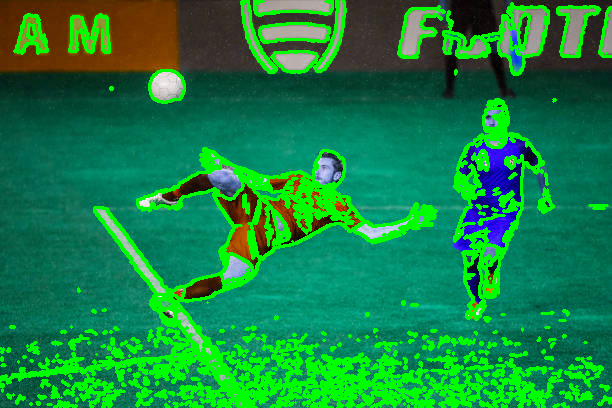

In [ ]:
# Task 1 — Find and Draw Contours
# Steps:

# Load your image, convert to grayscale
# Apply Canny (or threshold) to get a binary edge/mask image — contours need a binary input
# Use cv2.findContours — look up its three parameters :
#   (input image, retrieval mode, approximation method) and
#   what RETR_EXTERNAL vs RETR_TREE mean before picking one
# Use cv2.drawContours to draw the found contours onto a copy of the original image

import cv2
import matplotlib.pyplot as plt

img_bgr = cv2.imread("/content/football image.jpg")
gray = cv2.cvtColor(img_bgr,cv2.COLOR_BGR2GRAY)

canny = cv2.Canny(gray,100,150)

contour_Exter,hierarchy = cv2.findContours(
    canny,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

img_copy = img_bgr.copy()
cv2.drawContours(img_copy, contour_Exter, -1, (0,255,0), 2)


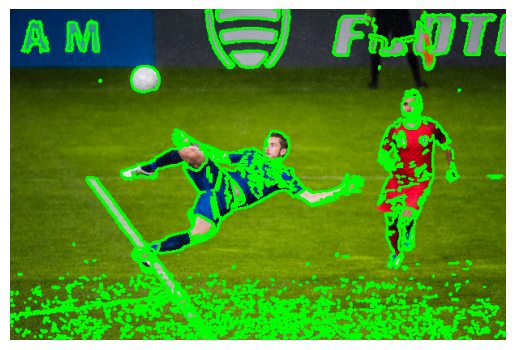

In [ ]:
# Task 2 — Filter Contours by Area
# Now clean it up. Loop through contour_Exter, and for each contour:

# Get its area using cv2.contourArea
# Only keep/draw it if the area is above some threshold
#  (you'll need to experiment — try something like 500 or 1000 as a
#   starting point and adjust based on the result)

for contour in contour_Exter:
  area = cv2.contourArea(contour)
  if area>1500:
    cv2.drawContours(img_copy,[contour],-1,(0,255,0),2)

#print(f"Contours drawn: {count}")
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Contours drawn: 4


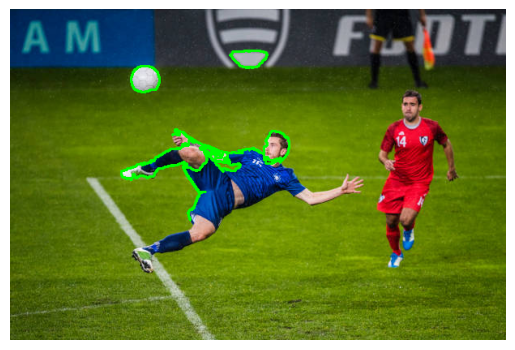

In [ ]:
# Task 2 — Filter Contours by Area
img_copy2 = img_bgr.copy()   # fresh copy, independent of Task 1's img_copy

count = 0
for contour in contour_Exter:
    area = cv2.contourArea(contour)
    if area > 500:
        cv2.drawContours(img_copy2, [contour], -1, (0,255,0), 2)
        count += 1

print(f"Contours drawn: {count}")
plt.imshow(cv2.cvtColor(img_copy2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
# Task 2.5 — Dilate Before Finding Contours
# Step 1 — Imports & Load
# Same as before: cv2, matplotlib.pyplot, numpy (new — you'll need it for the kernel). Load image, convert to grayscale.
# Step 2 — Canny
# Same as Day 4/5: cv2.Canny(gray, 100, 150) — no changes here.
# Step 3 — Create a kernel
# Look up np.ones() — it takes a shape (try (3,3)) and a dtype (should be np.uint8 for OpenCV to accept it).
# Step 4 — Dilate
# Look up cv2.dilate() — it takes: the binary image (your Canny output), the kernel,
#   and iterations (start with 1, you can experiment with 2 later if gaps are still too big).
# Step 5 — Find contours on the dilated image
# Same cv2.findContours() call as before, but pass the dilated result
#    instead of raw canny. Keep RETR_EXTERNAL and CHAIN_APPROX_SIMPLE.
# Step 6 — Filter and draw (fresh copy)
# Same loop as Task 2 — fresh img_bgr.copy(), loop through contours,
#   check cv2.contourArea(contour) > 1500, draw + count.
# Step 7 — Display
# Same plotting pattern — convert BGR→RGB, imshow, axis off, show.


Contours drawn: 9


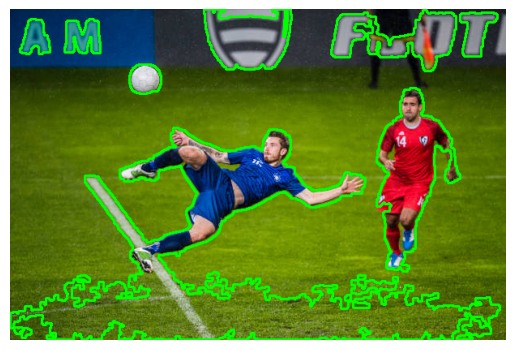

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_bgr = cv2.imread("/content/football image.jpg")
gray= cv2.cvtColor(img_bgr,cv2.COLOR_BGR2GRAY)

#step2
canny = cv2.Canny(gray,100,150)

#step3
kernel = np.ones((5,5),np.uint8)

#step4
dilation = cv2.dilate(canny,kernel,iterations = 1)

#step5
contour_Exter,hierarchy = cv2.findContours(
    dilation,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

#step6
img3 = img_bgr.copy()
for contour in contour_Exter :
  area = cv2.contourArea(contour)
  if area>500:
    cv2.drawContours(img3,[contour],-1,(0,255,0),2)


print(f"Contours drawn: {sum(1 for c in contour_Exter if cv2.contourArea(c) > 500)}")
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
# Task 6 — Filter by Aspect Ratio
# Goal: kill the leftover grass blob at the bottom while keeping the players and ball.
# Steps:

# Start fresh — new copy of the image (img_bgr.copy()), same as every task before.
# Loop through contour_Exter (the contours from the dilated image).
# For each contour, first check the area condition (like Task 2 — keep only if area > 500).
# If it passes area, get its bounding box: x, y, w, h = cv2.boundingRect(contour).
# Calculate aspect ratio: w / h.
# Think about the shapes before picking a cutoff:

# Players → taller than wide → aspect ratio less than 1
# Ball → roughly square → aspect ratio close to 1
# Grass blob → wide and short → aspect ratio well above 1


# Add a second if condition (nested inside the area check, or combined with and)
#  that only draws the contour if the aspect ratio is below some cutoff —
#    you'll need to test a value (try 1.0 or 1.2 as a starting guess).

# Draw the contour if it passes both conditions.
# Print count of contours drawn, then display like usual (BGR→RGB, imshow, axis off, show).

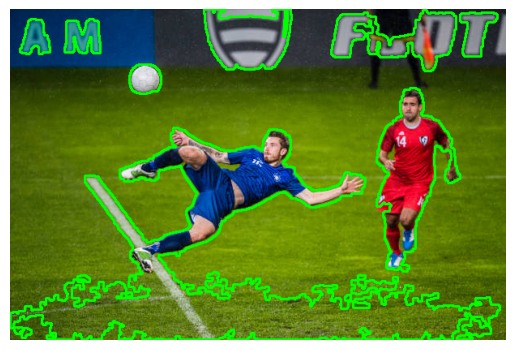

In [ ]:
#step1
img4 = img_bgr.copy()
#step2
for contour in contour_Exter:
  area = cv2.contourArea(contour)
  if area>500:
    x,y,w,h = cv2.boundingRect(contour)
    a_ratio = w/h
    if a_ratio<2.4:
      cv2.drawContours(img4,[contour],-1,(0,255,0),2)

plt.imshow(cv2.cvtColor(img4,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()